In [7]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from imports import *
from config import dir_config

In [9]:
processed_dir = Path(dir_config.data.processed)
glm_hmm_dir   = processed_dir / "glm_hmm"

desired_order = ["asmHC", "Tremor_OFF", "Brady_OFF", "Tremor_ON", "Brady_ON"]

# ── Load results saved by 5.20 and 5.23 ───────────────────────────────────────
bits_df   = pd.read_csv(glm_hmm_dir / "model_selection_bits_per_trial.csv", index_col=0)
mse_df    = pd.read_csv(glm_hmm_dir / "model_selection_psych_mse_cv.csv")
bits_k_df = pd.read_csv(glm_hmm_dir / "model_selection_best_k_bits.csv", index_col=0)
mse_k_df  = pd.read_csv(glm_hmm_dir / "model_selection_best_k_mse.csv",  index_col=0)

# bits_df: index=config, columns=groups + mean_bits
# mse_df:  long-form, columns: config, group, best_k, mse, sem
pivot_mse = mse_df.pivot(index="config", columns="group", values="mse").reindex(columns=desired_order)
pivot_mse["mean_mse"] = pivot_mse.mean(axis=1)

# ── Build per-config summary (inner join — only configs present in both metrics) ──
summary = pd.DataFrame({
    "mean_bits": bits_df["mean_bits"],
    "mean_mse":  pivot_mse["mean_mse"],
}).dropna()

missing_bits = set(pivot_mse.index) - set(bits_df.index)
missing_mse  = set(bits_df.index)   - set(pivot_mse.index)
if missing_bits:
    print(f"⚠ configs in MSE but not bits CSV (excluded): {missing_bits}")
if missing_mse:
    print(f"⚠ configs in bits but not MSE CSV (excluded): {missing_mse}")

summary["rank_bits"] = summary["mean_bits"].rank(ascending=False).astype(int)
summary["rank_mse"]  = summary["mean_mse"].rank(ascending=True).astype(int)
summary["combined_rank"] = (summary["rank_bits"] + summary["rank_mse"]) / 2
summary["rank_disagreement"] = (summary["rank_bits"] - summary["rank_mse"]).abs()
summary = summary.sort_values("combined_rank")

print(summary.to_string(float_format=lambda x: f"{x:.4f}"))

⚠ configs in MSE but not bits CSV (excluded): {'no_standardization_curr_stim_prev_choiceXtarget_no_prev_target'}
                                                                      mean_bits  mean_mse  rank_bits  rank_mse  combined_rank  rank_disagreement
config                                                                                                                                          
ashwood_matched                                                          0.2433    0.2552          2         1         1.5000                  1
no_standardization_curr_stim_color_prev_choiceXtarget_no_prev_target     0.2416    0.2601          4         2         3.0000                  2
no_standardization_curr_stim_color_prev_choiceXtarget                    0.2471    0.2790          1         7         4.0000                  6
normalized_stimulus_with_color                                           0.2406    0.2759          5         3         4.0000                  2
no_standardizatio

## Per-config × group detail

Both metrics evaluated on **held-out CV test data** — bits/trial (5.20) and psych MSE (5.23).
5.21 (psych MSE on final models) is excluded as it is in-sample and not comparable.

- **bits/trial**: higher = better; measures trial-level predictive accuracy (log-likelihood)
- **psych MSE**: lower = better; measures how well the model reproduces the psychometric curve shape

In [10]:
# Wide table: for each config, show bits/trial and psych MSE side by side per group
bits_groups = bits_df.drop(columns="mean_bits").reindex(columns=desired_order)
mse_groups  = pivot_mse.drop(columns="mean_mse").reindex(columns=desired_order)

configs = summary.index.tolist()
col_bits = {g: f"{g}_bits" for g in desired_order}
col_mse  = {g: f"{g}_mse"  for g in desired_order}

rows = []
for cfg in configs:
    row = {"config": cfg}
    for g in desired_order:
        row[col_bits[g]] = bits_groups.loc[cfg, g] if cfg in bits_groups.index else np.nan
        row[col_mse[g]]  = mse_groups.loc[cfg, g]  if cfg in mse_groups.index  else np.nan
    row["mean_bits"] = summary.loc[cfg, "mean_bits"]
    row["mean_mse"]  = summary.loc[cfg, "mean_mse"]
    row["rank_bits"] = summary.loc[cfg, "rank_bits"]
    row["rank_mse"]  = summary.loc[cfg, "rank_mse"]
    row["combined_rank"] = summary.loc[cfg, "combined_rank"]
    rows.append(row)

detail_df = pd.DataFrame(rows).set_index("config")
print(detail_df[["mean_bits", "rank_bits", "mean_mse", "rank_mse", "combined_rank"]]
      .to_string(float_format=lambda x: f"{x:.4f}"))

                                                                      mean_bits  rank_bits  mean_mse  rank_mse  combined_rank
config                                                                                                                       
ashwood_matched                                                          0.2433          2    0.2552         1         1.5000
no_standardization_curr_stim_color_prev_choiceXtarget_no_prev_target     0.2416          4    0.2601         2         3.0000
no_standardization_curr_stim_color_prev_choiceXtarget                    0.2471          1    0.2790         7         4.0000
normalized_stimulus_with_color                                           0.2406          5    0.2759         3         4.0000
no_standardization_curr_stim_color_no_prev_coh                           0.2392          7    0.2786         5         6.0000
standardized_stimulus                                                    0.2368          9    0.2775         4        

## Scatter: bits/trial vs psych MSE

Each point is one config. **Top-left quadrant = good on both metrics.**
Configs with low rank disagreement are highlighted.

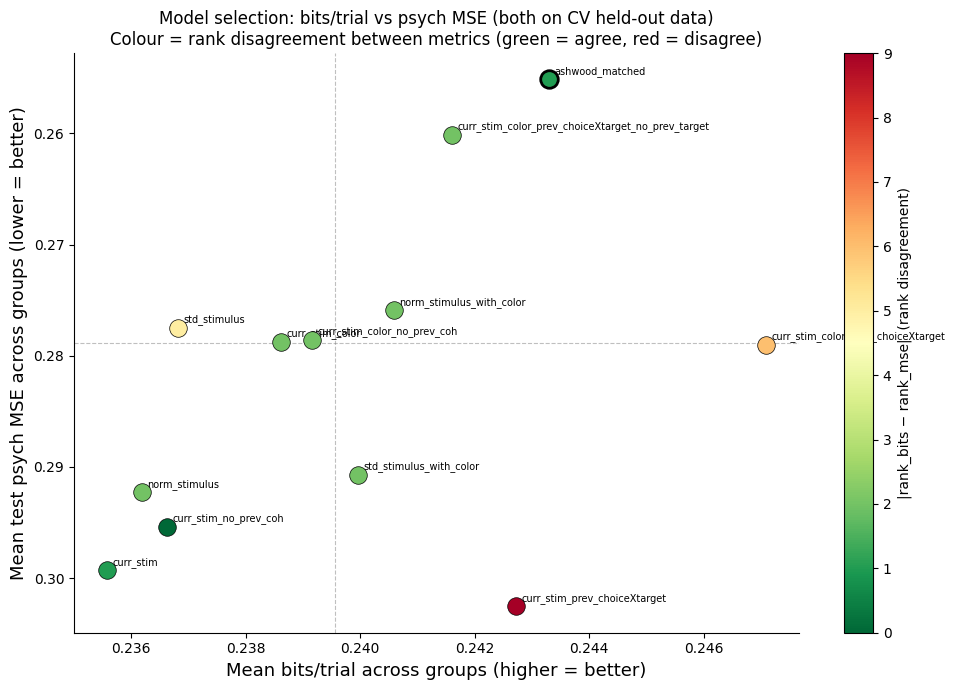

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))

max_disagree = summary["rank_disagreement"].max()
cmap = plt.cm.RdYlGn_r

for cfg, row in summary.iterrows():
    color = cmap(row["rank_disagreement"] / max_disagree)
    is_best = row["combined_rank"] == summary["combined_rank"].min()
    ax.scatter(row["mean_bits"], row["mean_mse"],
               s=160, color=color, zorder=5,
               edgecolors="black", linewidths=2.0 if is_best else 0.5)
    short = cfg.replace("no_standardization_", "").replace("normalized_", "norm_").replace("standardized_", "std_")
    ax.annotate(short, (row["mean_bits"], row["mean_mse"]),
                fontsize=7, xytext=(4, 4), textcoords="offset points")

# Quadrant lines at medians
ax.axvline(summary["mean_bits"].median(), color="gray", lw=0.8, ls="--", alpha=0.5)
ax.axhline(summary["mean_mse"].median(),  color="gray", lw=0.8, ls="--", alpha=0.5)

ax.set_xlabel("Mean bits/trial across groups (higher = better)", fontsize=13)
ax.set_ylabel("Mean test psych MSE across groups (lower = better)", fontsize=13)
ax.set_title("Model selection: bits/trial vs psych MSE (both on CV held-out data)\n"
             "Colour = rank disagreement between metrics (green = agree, red = disagree)",
             fontsize=12)
ax.invert_yaxis()  # lower MSE is better → flip so top-left = good on both
ax.spines[["top", "right"]].set_visible(False)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, max_disagree))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="|rank_bits − rank_mse|  (rank disagreement)")
plt.tight_layout()
plt.savefig(glm_hmm_dir / "model_selection_combined_scatter.png", bbox_inches="tight", dpi=150)
plt.show()

## Combined ranking

Average of rank-on-bits and rank-on-MSE. Configs where both metrics agree (low disagreement) are the most robust selections.

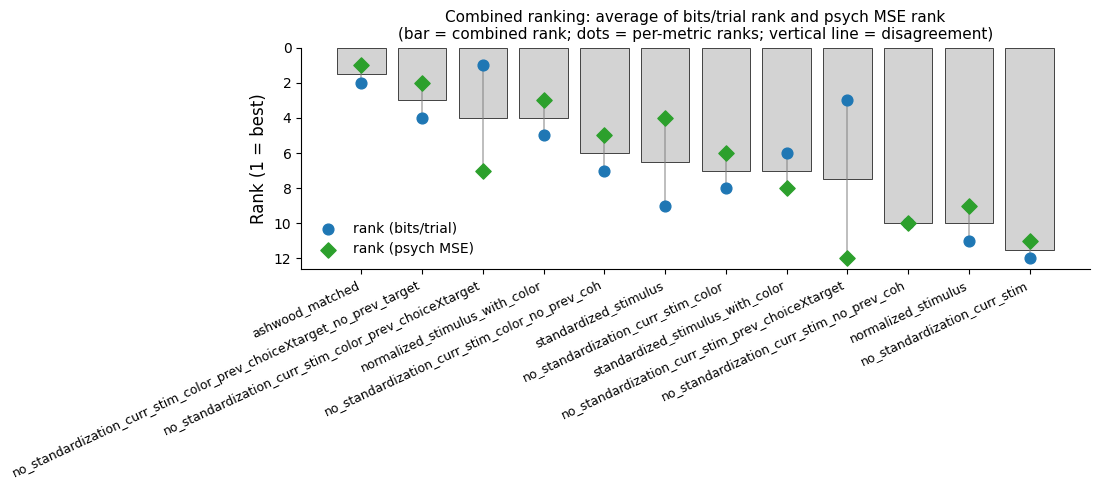


Final ranking (combined):

                                                                      rank_bits  rank_mse  combined_rank  rank_disagreement
config                                                                                                                     
ashwood_matched                                                               2         1            1.5                  1
no_standardization_curr_stim_color_prev_choiceXtarget_no_prev_target          4         2            3.0                  2
no_standardization_curr_stim_color_prev_choiceXtarget                         1         7            4.0                  6
normalized_stimulus_with_color                                                5         3            4.0                  2
no_standardization_curr_stim_color_no_prev_coh                                7         5            6.0                  2
standardized_stimulus                                                         9         4            6.5

In [12]:
configs_sorted = summary.index.tolist()
combined_ranks = summary["combined_rank"].values
rank_bits_vals = summary["rank_bits"].values
rank_mse_vals  = summary["rank_mse"].values
disagree_vals  = summary["rank_disagreement"].values

BITS_C, MSE_C = "tab:blue", "tab:green"

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(configs_sorted))

bars = ax.bar(x, combined_ranks, color="lightgray", edgecolor="black", linewidth=0.5, zorder=2)

# Overlay individual metric ranks as markers
ax.scatter(x, rank_bits_vals, color=BITS_C, s=60, zorder=5, label="rank (bits/trial)")
ax.scatter(x, rank_mse_vals,  color=MSE_C,  s=60, zorder=5, marker="D", label="rank (psych MSE)")

# Connect the two ranks per config to visualise disagreement
for xi, rb, rm in zip(x, rank_bits_vals, rank_mse_vals):
    ax.plot([xi, xi], [rb, rm], color="gray", lw=1.2, zorder=4, alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels(configs_sorted, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Rank (1 = best)", fontsize=12)
ax.set_title(
    "Combined ranking: average of bits/trial rank and psych MSE rank\n"
    "(bar = combined rank; dots = per-metric ranks; vertical line = disagreement)",
    fontsize=11,
)
ax.invert_yaxis()  # rank 1 at top
ax.legend(fontsize=10, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(glm_hmm_dir / "model_selection_combined_ranking.png", bbox_inches="tight", dpi=150)
plt.show()

print("\nFinal ranking (combined):\n")
print(summary[["rank_bits", "rank_mse", "combined_rank", "rank_disagreement"]].to_string())
print(f"\nBest config (combined):  {configs_sorted[0]}")
print(f"Most robust (min disagreement):  {summary['rank_disagreement'].idxmin()}")